<a href="https://colab.research.google.com/github/Karthik01018/-Logistic-Regression/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    roc_auc_score, roc_curve, classification_report
)

**Load and prepare a binary classification dataset**

In [2]:
df = pd.read_csv("/content/data.csv")
df = df.drop(columns=["id", "Unnamed: 32"])
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

**Train/test split and standardize features**

In [4]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 **Fit logistic regression model**

In [5]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

**Evaluate model performance**

In [6]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

**Confusion Matrix**

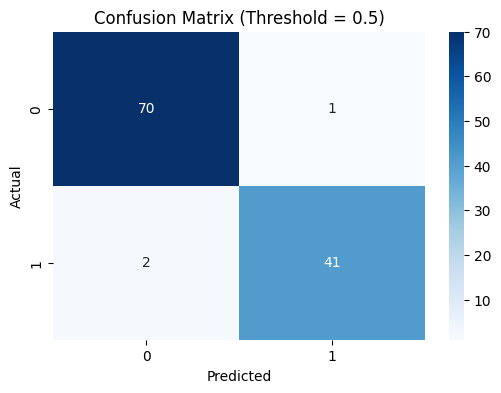

In [7]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Metrics**

In [8]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, ROC-AUC: {roc_auc:.2f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Precision: 0.98, Recall: 0.95, ROC-AUC: 1.00


**ROC Curve**

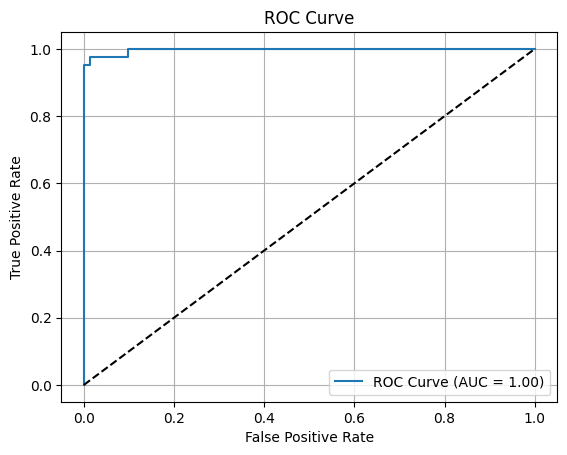

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

**Tune threshold and explain sigmoid**

In [10]:
thresholds = np.arange(0.1, 0.9, 0.1)
results = []

for t in thresholds:
    y_thresh = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_thresh)
    rec = recall_score(y_test, y_thresh)
    results.append((t, prec, rec))

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall"])

**Plot threshold tuning**

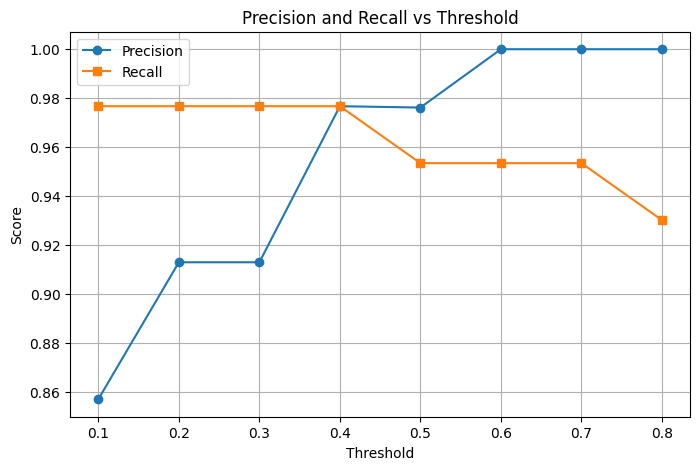

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision", marker='o')
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall", marker='s')
plt.title("Precision and Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

**Explanation of sigmoid**

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Visualize sigmoid curve**

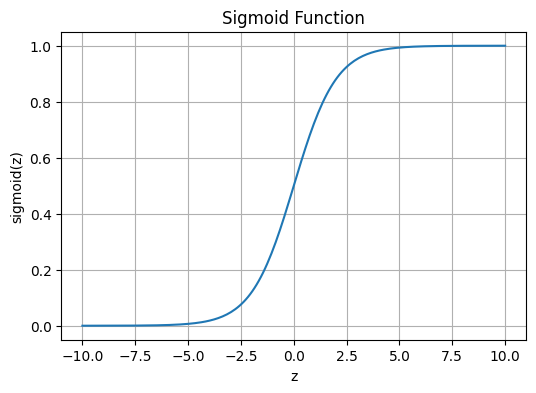

In [13]:
z_vals = np.linspace(-10, 10, 200)
sigmoid_vals = sigmoid(z_vals)

plt.figure(figsize=(6, 4))
plt.plot(z_vals, sigmoid_vals)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.show()